# Zomato Data Analysis Project

## Project Description:
#### In this project, we analyze a dataset of restaurant information from Zomato to uncover insights into customer behavior, restaurant preferences, and spending patterns. The dataset contains various attributes such as restaurant names, ratings, votes, types of restaurants, and spending data. The primary objective is to answer various key questions like identifying the most popular restaurant types, analyzing customer ratings, and understanding online vs offline order trends, etc.





### Key Questions:
1. What type of restaurants do the majority of customers order from?
2. How many votes has each type of restaurant received from customers?
3. What are the ratings that the majority of restaurants have received?
4. Zomato has observed that most couples order most of their food online. What is their
    average spending on each order?
5. Which mode (online or offline) has received the maximum rating?
6. Which types of restaurants received more offline orders, and how can Zomato use this data to offer better deals?


### Step 1 - Importing Libraries

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Step 2 - Create the data frame

In [10]:
dataframe = pd.read_csv("Zomato data .csv")
print(dataframe)

                      name online_order book_table   rate  votes  \
0                    Jalsa          Yes        Yes  4.1/5    775   
1           Spice Elephant          Yes         No  4.1/5    787   
2          San Churro Cafe          Yes         No  3.8/5    918   
3    Addhuri Udupi Bhojana           No         No  3.7/5     88   
4            Grand Village           No         No  3.8/5    166   
..                     ...          ...        ...    ...    ...   
143       Melting Melodies           No         No  3.3/5      0   
144        New Indraprasta           No         No  3.3/5      0   
145           Anna Kuteera          Yes         No  4.0/5    771   
146                 Darbar           No         No  3.0/5     98   
147          Vijayalakshmi          Yes         No  3.9/5     47   

     approx_cost(for two people) listed_in(type)  
0                            800          Buffet  
1                            800          Buffet  
2                            8

In [3]:
dataframe

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet
...,...,...,...,...,...,...,...
143,Melting Melodies,No,No,3.3/5,0,100,Dining
144,New Indraprasta,No,No,3.3/5,0,150,Dining
145,Anna Kuteera,Yes,No,4.0/5,771,450,Dining
146,Darbar,No,No,3.0/5,98,800,Dining


### Step 3 - Data Cleaning

#### Handling the 'rate' column

In [11]:
def HandleRate(value):       #defines a function named HandleRate that will take one input called value (each value from the rate column).

    value = str(value).split('/')   #Convert the value into a string (if it's not already), then split the string wherever there is a ('/')
    value = value[0]               
    return float(value)


dataframe['rate'] = dataframe['rate'].apply(HandleRate)  #For every entry in the rate column, apply the handleRate function.
print(dataframe.head())          #Print the first 5 rows of the updated dataframe to check if the rate column has been successfully cleaned.



                    name online_order book_table  rate  votes  \
0                  Jalsa          Yes        Yes   4.1    775   
1         Spice Elephant          Yes         No   4.1    787   
2        San Churro Cafe          Yes         No   3.8    918   
3  Addhuri Udupi Bhojana           No         No   3.7     88   
4          Grand Village           No         No   3.8    166   

   approx_cost(for two people) listed_in(type)  
0                          800          Buffet  
1                          800          Buffet  
2                          800          Buffet  
3                          300          Buffet  
4                          600          Buffet  


#### Checking for Null Values

In [12]:
dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         148 non-null    object 
 1   online_order                 148 non-null    object 
 2   book_table                   148 non-null    object 
 3   rate                         148 non-null    float64
 4   votes                        148 non-null    int64  
 5   approx_cost(for two people)  148 non-null    int64  
 6   listed_in(type)              148 non-null    object 
dtypes: float64(1), int64(2), object(4)
memory usage: 8.2+ KB


#### Conclusion : There are no missing or null values in the dataset

### "Type of restaurant"

Text(0.5, 0, 'Type Of Restaurant')

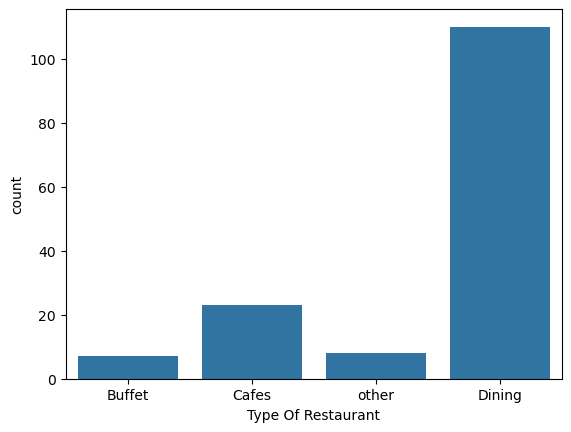

In [17]:
# Create a count plot for the 'listed_in(type)' column of the dataframe
sns.countplot(x = dataframe['listed_in(type)'])

# Set the label for the x-axis to indicate the type of restaurant
plt.xlabel("Type Of Restaurant")

#### Conclusion: The majority of the restaurants fall into the dining category.
#### So, the dining restaurants are preferred by large number of individuals.

### "Total Votes Received by Each Type of Restaurant"

Text(0, 0.5, 'Votes')

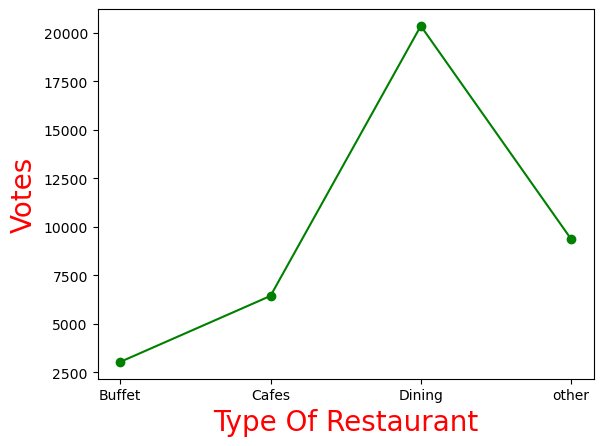

In [15]:
grouped_data = dataframe.groupby('listed_in(type)')['votes'].sum()
result = pd.DataFrame({'votes' : grouped_data})      # Convert the grouped data (a pandas Series) into a DataFrame for easier manipulation
plt.plot(result, c="green", marker="o")
plt.xlabel("Type Of Restaurant", c="red", size=20)
plt.ylabel("Votes", c="red", size=20)


#### Conclusion: Dining restaurant has received maximum votes

### "Ratings Received by the Majority of Restaurants"

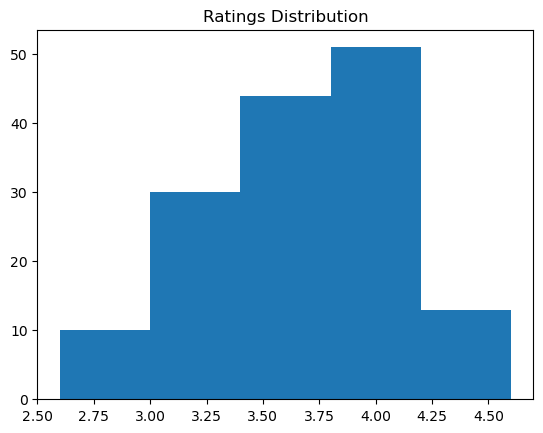

In [18]:
plt.hist(dataframe['rate'], bins=5)
plt.title("Ratings Distribution")
plt.show()

#### Conclusion: The majority of restaurants received ratings ranging from 3.5 to 4

### "Average Spending per Order by Couples"

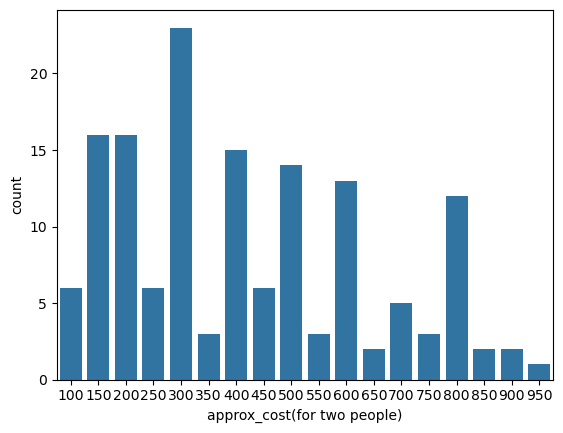

In [23]:
couple_data = dataframe['approx_cost(for two people)']
sns.countplot(x=couple_data)
plt.show()

#### Conclusion: The majority of couples prefer restaurants with an approximate cost of 300 rupees.

### "Mode (Online or Offline) with Maximum Rating"

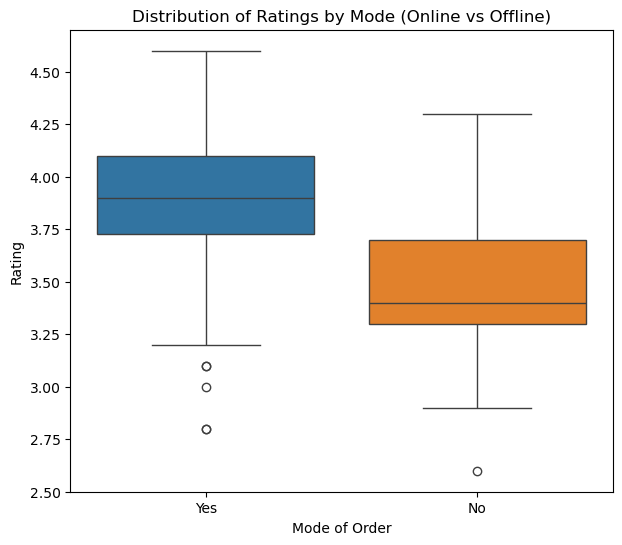

In [35]:
# Create a box plot to visualize the distribution of ratings by 'online_order' (Online vs Offline)
plt.figure(figsize=(7, 6))
sns.boxplot(x='online_order', y='rate', data=dataframe, hue='online_order')
plt.title("Distribution of Ratings by Mode (Online vs Offline)")
plt.xlabel("Mode of Order")
plt.ylabel("Rating")
plt.show()


#### Conclusion: Offline orders received lower ratings in comparison to online orders, which obtained excellent ratings.

### "Restaurant Type with Maximum Offline Orders"

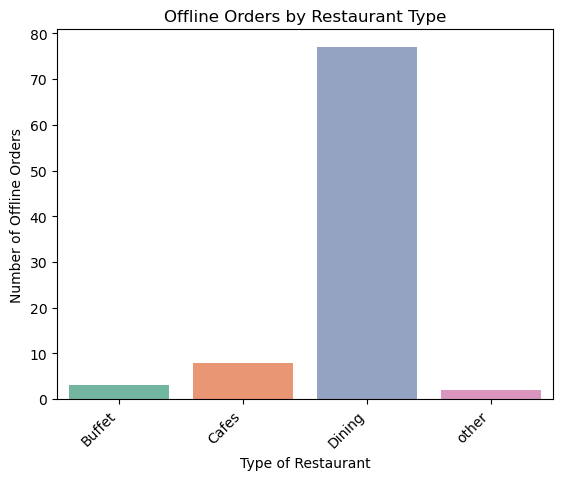

In [41]:
# Visualize offline orders by restaurant type with a specific color palette
sns.countplot(x='listed_in(type)', data=offline_orders, hue='listed_in(type)', palette='Set2', legend=False)

# Set title and labels for clarity
plt.title("Offline Orders by Restaurant Type")
plt.xlabel("Type of Restaurant")
plt.ylabel("Number of Offline Orders")

# Rotate the x-axis labels by 45 degrees and align them to the right
plt.xticks(rotation=45, ha='right')

# Display the plot
plt.show()


#### Conclusion: Dining restaurants receive more offline orders, indicating greater customer preference for a full-service dining experience over buffets, cafes, and other types of eateries.